In [1]:
# Install Libraries
!pip3 install pandas matplotlib seaborn numpy

In [2]:
# Import Libraries
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [11]:
# Read in Data for EDA
url_raw = 'https://raw.githubusercontent.com/Noah-Gallego/Plot-A-Thon/main/gamer_study_raw.csv'
url_clean = 'https://raw.githubusercontent.com/Noah-Gallego/Plot-A-Thon/main/Noah/data/parents_cleaned.csv'

df_raw = pd.read_csv(url_raw)
parents = pd.read_csv(url_clean)

In [12]:
df_raw.head()

,respondent_id,age,generation,gender,race_ethnicity_primary,lgbt_identification,is_player,is_parent,children_play_games,motivation_relax_or_pass_time,...,teach_communication_likert,teach_inclusive_attitudes_likert,teach_conflict_resolution_likert,teach_leadership_likert,plays_sport_irl,plays_video_sport_version,belief_video_sport_improves_performance,discover_song_from_game,discover_show_from_game,discover_game_from_show
0,1,26.0,Gen Z,Female,White/Caucasian,No,FALSE,False,False,0.0,...,3,5,2,5,True,False,False,False,False,False
1,2,63.0,Boomer,Female,Hispanic,No,TRUE,False,False,1.0,...,3,2,3,4,False,False,True,False,False,False
2,3,76.0,Boomer,Male,White/Caucasian,No,TRUE,False,False,0.0,...,4,5,4,2,False,False,True,False,False,False
3,4,34.0,Millennial,Nonbinary/Other,White/Caucasian,No,TRUE,True,True,1.0,...,4,2,5,5,False,False,True,False,False,True
4,5,29.0,Millennial,Male,Black/African American,No,TRUE,True,True,1.0,...,5,1,2,3,False,False,False,True,True,False


In [13]:
parents.head()

,age,generation,gender,race_ethnicity_primary,is_player,is_parent,children_play_games,motivation_relax_or_pass_time,motivation_have_fun,motivation_keep_mind_sharp,...,teach_communication_likert,teach_inclusive_attitudes_likert,teach_conflict_resolution_likert,teach_leadership_likert,plays_sport_irl,plays_video_sport_version,belief_video_sport_improves_performance,discover_song_from_game,discover_show_from_game,discover_game_from_show
0,34.0,3,2.0,5.0,1,1,1,1.0,1.0,1,...,4,2,5,5,0,0,1,0,0,1
1,29.0,3,1.0,1.0,1,1,1,1.0,1.0,0,...,5,1,2,3,0,0,0,1,1,0
2,40.0,3,0.0,5.0,0,1,1,0.0,0.0,0,...,1,5,4,4,1,0,0,0,0,0
3,57.0,1,0.0,4.0,1,1,1,1.0,1.0,1,...,3,4,4,3,0,0,1,0,0,0
4,36.0,3,NaN,5.0,1,1,1,1.0,0.0,0,...,4,4,1,3,0,0,1,1,0,0


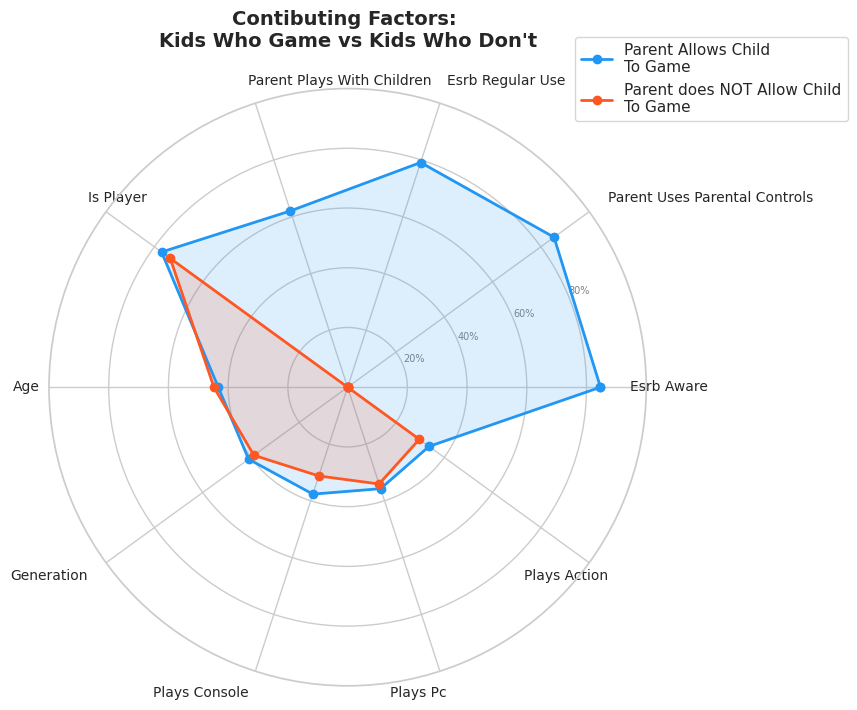

In [26]:
# Apply seaborn styling
sns.set_style("whitegrid")
sns.set_context("notebook")

features = [
    'esrb_aware',
    'parent_uses_parental_controls',
    'esrb_regular_use',
    'parent_plays_with_children',
    'is_player',
    'age',
    'generation',
    'plays_console',
    'plays_pc',
    'plays_action',
]

# Compute group means
group_yes = parents[parents['children_play_games'] == 1][features].mean()
group_no  = parents[parents['children_play_games'] == 0][features].mean()

# Normalize to 0-100 using full dataset min/max
feat_min = parents[features].min()
feat_max = parents[features].max()
feat_range = feat_max - feat_min
feat_range[feat_range == 0] = 1

group_yes_norm = ((group_yes - feat_min) / feat_range) * 100
group_no_norm  = ((group_no - feat_min) / feat_range) * 100

# Radar chart setup
labels = [f.replace('_', ' ').title() for f in features]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

values_yes = group_yes_norm.tolist() + [group_yes_norm.tolist()[0]]
values_no  = group_no_norm.tolist() + [group_no_norm.tolist()[0]]

# Plot
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

ax.plot(angles, values_yes, 'o-', linewidth=2, label='Parent Allows Child\nTo Game', color='#2196F3')
ax.fill(angles, values_yes, alpha=0.15, color='#2196F3')

ax.plot(angles, values_no, 'o-', linewidth=2, label="Parent does NOT Allow Child\nTo Game", color='#FF5722')
ax.fill(angles, values_no, alpha=0.15, color='#FF5722')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10, ha='center')

# Adjust label positions so they don't overlap the chart
for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    if angle in (0, np.pi):
        label.set_horizontalalignment('center')
    elif 0 < angle < np.pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')

ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(['20%', '40%', '60%', '80%'], size=7, color='gray')
ax.set_title('Contibuting Factors: \nKids Who Game vs Kids Who Don\'t', size=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), frameon=True)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()